# 04 문제 1 (기본) - 인구조사 소득 이진분류 개선

## 데이터
제공 데이터: `04_이진분류/train.csv`, `test.csv` (미국 인구조사 1994, 노트북과 같은 폴더).
타겟: `income` (`<=50K` / `>50K`).

## 문제
강의 04의 워크플로우를 기반으로 아래를 수행하라.

1. **(필수)** 강의 04 코드를 그대로 실행해 검증 정확도와 ROC-AUC를 재현하라.
2. `RandomForestClassifier`의 `n_estimators`를 100 -> 300으로 바꾸면 ROC-AUC가 어떻게 변하는가? 값을 비교하라.
3. `RandomForestClassifier` 대신 `LightGBM`(`import lightgbm as lgb; lgb.LGBMClassifier(random_state=0, verbose=-1)`)으로 학습해 ROC-AUC를 비교하라.
4. `classification_report`를 출력하고, `>50K`(양성)의 recall이 낮은 이유를 **불균형** 관점에서 2~3문장으로 설명하라.

## 채점 포인트
- train 기준값으로 test를 채웠는가(데이터 누수 방지)
- get_dummies를 train+test 합쳐서 했는가
- 불균형 데이터에서 정확도 대신 ROC-AUC를 근거로 판단했는가

## 힌트
- 결측치: 수치형 중앙값, 범주형 최빈값
- 평가: `roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])`


In [ ]:
# IMPORT

In [1]:
import pandas as pd
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
# train = pd.read_csv('https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part2/ch2/train.csv')
# test = pd.read_csv('https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part2/ch2/test.csv')

print('train:', train.shape, '| test:', test.shape)

train: (29304, 16) | test: (3257, 15)


In [ ]:
# EDA

In [2]:
train.head(5)

,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,3331,34.0,State-gov,177331,Some-college,10,Married-civ-spouse,Prof-specialty,Husband,Black,Male,4386,0,40.0,United-States,>50K
1,19749,58.0,Private,290661,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40.0,United-States,<=50K
2,1157,48.0,Private,125933,Some-college,10,Widowed,Exec-managerial,Unmarried,Black,Female,0,1669,38.0,United-States,<=50K
3,693,58.0,Private,100313,Some-college,10,Married-civ-spouse,Protective-serv,Husband,White,Male,0,1902,40.0,United-States,>50K
4,12522,41.0,Private,195661,Some-college,10,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,54.0,United-States,<=50K


In [3]:
test.head()

,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,11574,39.0,State-gov,114055,Bachelors,13,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,40.0,United-States
1,15847,38.0,Private,254114,Some-college,10,Married-spouse-absent,Prof-specialty,Own-child,Black,Female,0,0,40.0,United-States
2,17655,44.0,State-gov,55395,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Male,0,0,NaN,United-States
3,19790,47.0,Private,28035,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50.0,United-States
4,31812,62.0,NaN,186611,HS-grad,9,Never-married,NaN,Not-in-family,White,Male,0,0,40.0,United-States


In [4]:
train.describe()

,id,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,29304.000000,29292.000000,2.930400e+04,29304.000000,29304.000000,29304.000000,29291.000000
mean,16264.027880,38.553223,1.897488e+05,10.080842,1093.858722,86.744506,40.434229
std,9384.518323,13.628811,1.055250e+05,2.570824,7477.435640,401.518928,12.324036
min,0.000000,-38.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,8145.750000,28.000000,1.177890e+05,9.000000,0.000000,0.000000,40.000000
50%,16253.500000,37.000000,1.783765e+05,10.000000,0.000000,0.000000,40.000000
75%,24374.250000,48.000000,2.370682e+05,12.000000,0.000000,0.000000,45.000000
max,32560.000000,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
test.describe()

,id,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,3257.000000,3251.000000,3.257000e+03,3257.000000,3257.000000,3257.000000,3248.000000
mean,16423.704943,38.802830,1.900447e+05,10.079214,931.804728,92.336199,40.468288
std,9535.416746,13.917588,1.057902e+05,2.590118,6496.962999,415.732721,12.598546
min,3.000000,17.000000,1.882700e+04,1.000000,0.000000,0.000000,1.000000
25%,8078.000000,28.000000,1.186520e+05,9.000000,0.000000,0.000000,40.000000
50%,16626.000000,37.000000,1.783190e+05,10.000000,0.000000,0.000000,40.000000
75%,24743.000000,48.000000,2.364360e+05,12.000000,0.000000,0.000000,45.000000
max,32559.000000,90.000000,1.033222e+06,16.000000,99999.000000,3900.000000,99.000000


In [10]:
train.tail(5)

,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
29299,15999,28.0,Private,47168,10th,6,Never-married,Machine-op-inspct,Own-child,White,Female,0,0,40.0,United-States,<=50K
29300,21604,44.0,Local-gov,231793,Doctorate,16,Married-spouse-absent,Prof-specialty,Unmarried,White,Female,0,0,38.0,United-States,<=50K
29301,26839,41.0,Local-gov,201435,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,Black,Male,0,0,40.0,United-States,<=50K
29302,16681,43.0,Private,137722,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40.0,United-States,<=50K
29303,16069,22.0,Private,406978,Bachelors,13,Never-married,Exec-managerial,Other-relative,White,Female,0,0,40.0,United-States,<=50K


In [11]:
train.sample(5)

,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
11722,20173,60.0,Self-emp-not-inc,89884,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,50.0,United-States,<=50K
13343,7707,37.0,NaN,172256,Some-college,10,Married-civ-spouse,NaN,Husband,White,Male,0,0,20.0,United-States,<=50K
11647,24902,50.0,Private,283676,Some-college,10,Divorced,Craft-repair,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
16577,23850,40.0,Private,272343,HS-grad,9,Married-civ-spouse,Adm-clerical,Wife,White,Female,0,0,40.0,United-States,>50K
21973,27450,42.0,Private,121055,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,60.0,United-States,<=50K


In [6]:
# 데이터 크기 확인
train.shape, test.shape

((29304, 16), (3257, 15))

In [7]:
# 자료형 타입 확인
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29304 entries, 0 to 29303
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              29304 non-null  int64  
 1   age             29292 non-null  float64
 2   workclass       27642 non-null  object 
 3   fnlwgt          29304 non-null  int64  
 4   education       29304 non-null  object 
 5   education.num   29304 non-null  int64  
 6   marital.status  29304 non-null  object 
 7   occupation      27636 non-null  object 
 8   relationship    29304 non-null  object 
 9   race            29304 non-null  object 
 10  sex             29304 non-null  object 
 11  capital.gain    29304 non-null  int64  
 12  capital.loss    29304 non-null  int64  
 13  hours.per.week  29291 non-null  float64
 14  native.country  28767 non-null  object 
 15  income          29304 non-null  object 
dtypes: float64(2), int64(5), object(9)
memory usage: 3.6+ MB


/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future ve

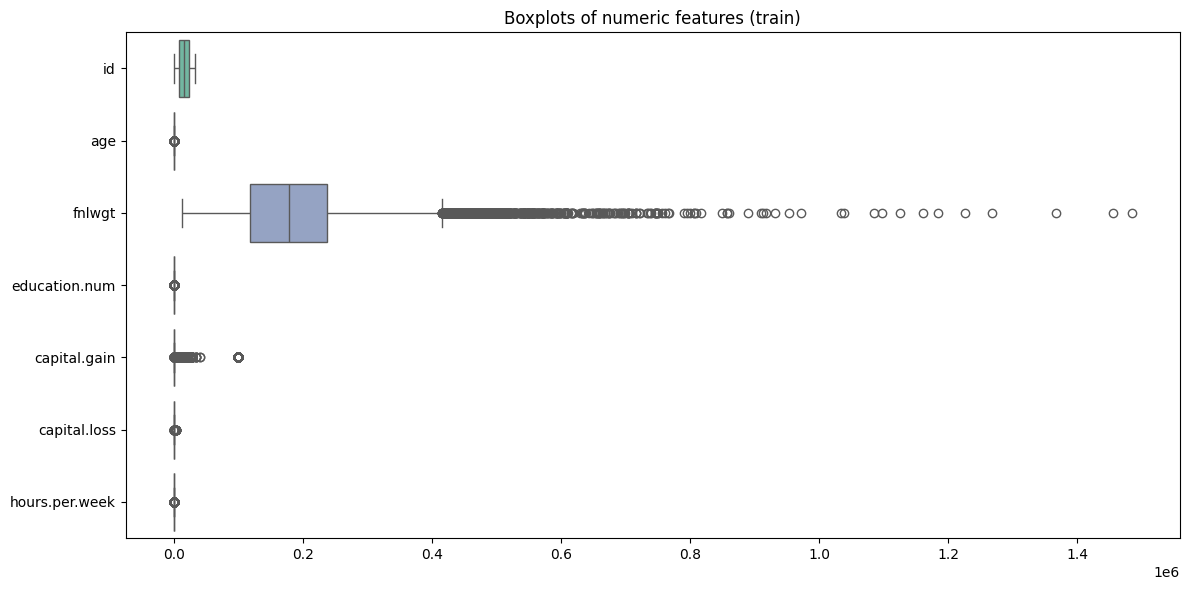

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 수치형 컬럼만 추출
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 6))
sns.boxplot(data=train[numeric_cols], orient="h", palette="Set2")
plt.title("Boxplots of numeric features (train)")
plt.tight_layout()
plt.show()

In [ ]:
# 데이터 전처리

In [10]:
num_cols = ['age', 'hours.per.week']  # 수치형 데이터
cat_cols = ['workclass', 'occupation', 'native.country'] # 범주형 데이터

for c in num_cols:
    m = train[c].median()            # train 기준 중앙값
    train[c] = train[c].fillna(m)
    test[c] = test[c].fillna(m)
    
for c in cat_cols:
    m = train[c].mode()[0]           # train 기준 최빈값
    train[c] = train[c].fillna(m)
    test[c] = test[c].fillna(m)
    
print('남은 결측치:', train.isnull().sum().sum(), test.isnull().sum().sum())

남은 결측치: 0 0


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29304 entries, 0 to 29303
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              29304 non-null  int64  
 1   age             29304 non-null  float64
 2   workclass       29304 non-null  object 
 3   fnlwgt          29304 non-null  int64  
 4   education       29304 non-null  object 
 5   education.num   29304 non-null  int64  
 6   marital.status  29304 non-null  object 
 7   occupation      29304 non-null  object 
 8   relationship    29304 non-null  object 
 9   race            29304 non-null  object 
 10  sex             29304 non-null  object 
 11  capital.gain    29304 non-null  int64  
 12  capital.loss    29304 non-null  int64  
 13  hours.per.week  29304 non-null  float64
 14  native.country  29304 non-null  object 
 15  income          29304 non-null  object 
dtypes: float64(2), int64(5), object(9)
memory usage: 3.6+ MB


In [12]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3257 entries, 0 to 3256
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              3257 non-null   int64  
 1   age             3257 non-null   float64
 2   workclass       3257 non-null   object 
 3   fnlwgt          3257 non-null   int64  
 4   education       3257 non-null   object 
 5   education.num   3257 non-null   int64  
 6   marital.status  3257 non-null   object 
 7   occupation      3257 non-null   object 
 8   relationship    3257 non-null   object 
 9   race            3257 non-null   object 
 10  sex             3257 non-null   object 
 11  capital.gain    3257 non-null   int64  
 12  capital.loss    3257 non-null   int64  
 13  hours.per.week  3257 non-null   float64
 14  native.country  3257 non-null   object 
dtypes: float64(2), int64(5), object(8)
memory usage: 381.8+ KB


In [ ]:
# train 에서 y값 분리

In [21]:
train.head()

,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,3331,34.0,State-gov,177331,Some-college,10,Married-civ-spouse,Prof-specialty,Husband,Black,Male,4386,0,40.0,United-States,>50K
1,19749,58.0,Private,290661,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40.0,United-States,<=50K
2,1157,48.0,Private,125933,Some-college,10,Widowed,Exec-managerial,Unmarried,Black,Female,0,1669,38.0,United-States,<=50K
3,693,58.0,Private,100313,Some-college,10,Married-civ-spouse,Protective-serv,Husband,White,Male,0,1902,40.0,United-States,>50K
4,12522,41.0,Private,195661,Some-college,10,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,54.0,United-States,<=50K


In [14]:
y = train['income'].map({'<=50K': 0, '>50K': 1})   # 문자 → 0/1
y

0        1
1        0
2        0
3        1
4        0
        ..
29299    0
29300    0
29301    0
29302    0
29303    0
Name: income, Length: 29304, dtype: int64

In [15]:
train.shape

(29304, 16)

In [16]:
train = train.drop(columns=['id', 'income'])
train.shape

(29304, 14)

In [17]:
test.shape

(3257, 15)

In [18]:
test_id = test['id']                                # 제출용 보관
test = test.drop(columns=['id'])

In [19]:
test.shape

(3257, 14)

In [20]:
all_df = pd.concat([train, test], axis=0)           # 합쳐서 인코딩
all_oh = pd.get_dummies(all_df)


In [31]:
all_df['marital.status'].unique()

array(['Married-civ-spouse', 'Widowed', 'Divorced', 'Never-married',
       'Married-spouse-absent', 'Separated', 'Married-AF-spouse'],
      dtype=object)

In [25]:
all_oh

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,34.0,177331,10,4386,0,40.0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,58.0,290661,9,0,0,40.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,48.0,125933,10,0,1669,38.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,58.0,100313,10,0,1902,40.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,41.0,195661,10,0,0,54.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3252,28.0,202558,10,0,0,40.0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3253,52.0,94391,9,0,0,40.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3254,25.0,109526,9,0,0,38.0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3255,36.0,242713,9,0,0,40.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False


In [32]:
X = all_oh.iloc[:len(train)]                        # 다시 train 부분
X_test = all_oh.iloc[len(train):]                   # test 부분
print('인코딩 후 컬럼 수:', X.shape[1])

인코딩 후 컬럼 수: 105


In [ ]:
# 검증 데이터 분할

In [33]:
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y)
print(X_tr.shape, X_val.shape)

(23443, 105) (5861, 105)


In [ ]:
# 데이터 학습

In [34]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_tr, y_tr)

RandomForestClassifier(random_state=0)

In [ ]:
# 모델 검증 지표

In [36]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
pred = rf.predict(X_val)
print(pred)
proba = rf.predict_proba(X_val)[:, 1]   # 1(>50K)일 확률 열만 (2차원 슬라이싱)
print(proba)
print('정확도 :', round(accuracy_score(y_val, pred), 4))
print('ROC-AUC:', round(roc_auc_score(y_val, proba), 4))
# # print(classification_report(y_val, pred))

[1 0 1 ... 0 0 0]
[0.58 0.02 0.91 ... 0.   0.   0.  ]
정확도 : 0.8528
ROC-AUC: 0.9014


In [ ]:
# 8) test 예측 & 제출 파일

In [40]:
X_test

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,39.0,114055,13,0,0,40.0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38.0,254114,10,0,0,40.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,44.0,55395,9,0,0,40.0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,47.0,28035,13,0,0,50.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,62.0,186611,9,0,0,40.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3252,28.0,202558,10,0,0,40.0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3253,52.0,94391,9,0,0,40.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3254,25.0,109526,9,0,0,38.0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3255,36.0,242713,9,0,0,40.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False


In [41]:
rf.predict_proba(X_test)

array([[0.99, 0.01],
       [0.98, 0.02],
       [0.91, 0.09],
       ...,
       [0.86, 0.14],
       [0.99, 0.01],
       [0.97, 0.03]], shape=(3257, 2))

In [43]:
test_proba = rf.predict_proba(X_test)[:, 1]
submit = pd.DataFrame({'id': test_id, 'income': test_proba})
submit.to_csv('submission.csv', index=False)   # index=False 필수
submit.head(15)

,id,income
0,11574,0.01
1,15847,0.02
2,17655,0.09
3,19790,0.97
4,31812,0.04
5,7548,0.14
6,13093,0.49
7,18332,0.20
8,28474,0.27
9,4213,0.00
